In [ ]:
# hf - a company

# libs - accelerate,

# transformers - based on the namw trans arch
# diffusion mechanism - behind image ml models
# diffusers - another lib by hf

In [1]:
! pip install datasets evaluate transformers diffusers accelerate ftfy pyarrow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 768.7 kB/s eta 0:00:00


In [11]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [2]:
import torch
from diffusers import (
    StableDiffusionPipeline, # text to image use-cases
    StableDiffusionImg2ImgPipeline # image to image use-cases
)

from PIL import Image
import requests
from io import BytesIO

torch_device = "cuda" if torch.cuda.is_available() else "cpu"

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


### Some examples

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/90 [00:00<?, ?it/s]

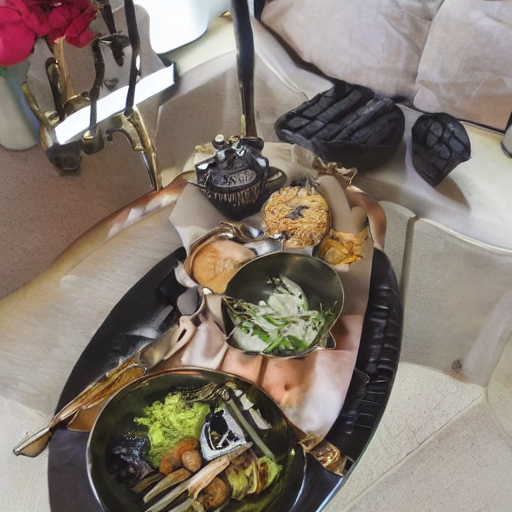

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/data/generated_image.png'

In [12]:
# -------------------------------------
# 1. TEXT-TO-IMAGE GENERATION
# -------------------------------------


pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16
).to(torch_device) # pipe = model

# Example prompt
prompt = "A majestic lion wearing a crown, photorealistic, 4k, highly detailed" # set whatever
prompt = "A nice Indian vegetarian Thali served in a banana leaf with a royal platter and with flowers decorated   , photorealistic, 4k, highly detailed"
image = pipe(prompt, num_inference_steps=90, guidance_scale=0).images[0]

display(image)

# Save & display
output_path = "/content/drive/MyDrive/data/generated_image.png"
image.save(output_path)
print(f"\nImage saved to: {output_path}")

# prompt 1 - toooo detailed, high guidance scale
# prompt 2 - not so detailed, low
"""
📝 Parameters explained:
- prompt: text description of the image
- num_inference_steps: how many denoising steps (higher = better quality, slower)
- guidance_scale: how strongly the prompt guides generation (7-8 is common; higher = more prompt fidelity, lower = more creativity)
"""



Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

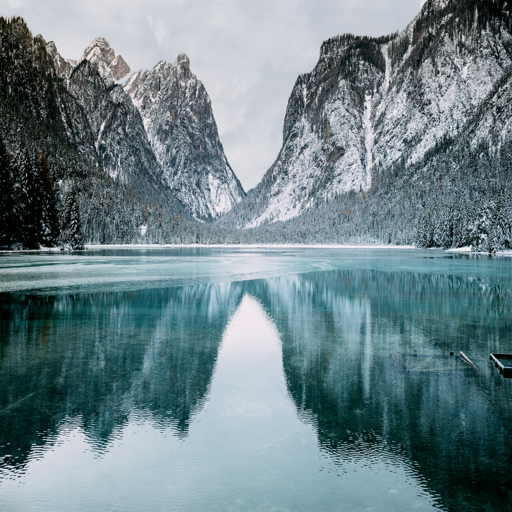

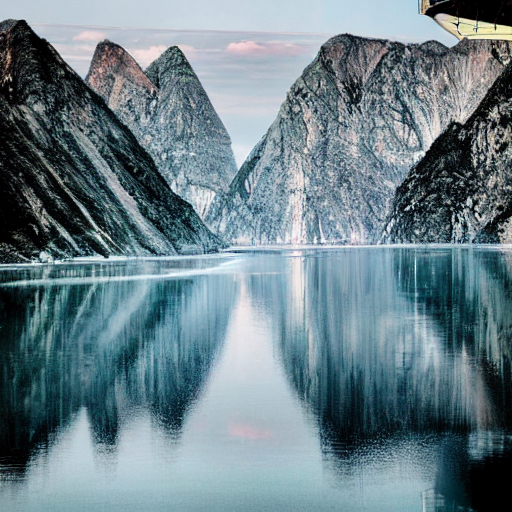

'\n📝 Parameters explained:\n- image: input image you want to transform\n- strength: controls how much noise is added\n    - low strength (0.2-0.4): keeps input structure, small edits\n    - high strength (0.7-0.9): more creative, diverges from input\n'

In [ ]:
# -------------------------------------
# 2. IMAGE-TO-IMAGE GENERATION
# -------------------------------------

img2img_pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16
).to(torch_device) # img2img_pipe = model


url = "https://images.unsplash.com/photo-1480497490787-505ec076689f?q=80&w=2069&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
init_image = Image.open(BytesIO(requests.get(url).content)).convert("RGB").resize((512, 512))

prompt = "A futuristic city skyline painted on the mountain"
strength = 0.7  # how much noise to add: 0 = almost same as input, 1 = ignore input
num_inference_steps = 40

img2img = img2img_pipe(
    prompt=prompt,
    image=init_image,
    strength=strength, # amt of noised added to the init img
    num_inference_steps=num_inference_steps, # bigger the number, more refined your image "might" be
    guidance_scale=7.5 # relates to the prompt - how much the model is gonna stick to the prompt
).images[0]

display(init_image)
display(img2img)

"""
📝 Parameters explained:
- image: input image you want to transform
- strength: controls how much noise is added
    - low strength (0.2-0.4): keeps input structure, small edits
    - high strength (0.7-0.9): more creative, diverges from input
"""

